# Multiple Linear Regression in StatsModels - Lab

## Introduction
In this lab, you'll practice fitting a multiple linear regression model on the Ames Housing dataset!

## Objectives

You will be able to:

* Perform a multiple linear regression using StatsModels
* Visualize individual predictors within a multiple linear regression
* Interpret multiple linear regression coefficients from raw, un-transformed data

## The Ames Housing Dataset

The [Ames Housing dataset](http://jse.amstat.org/v19n3/decock.pdf) is a newer (2011) replacement for the classic Boston Housing dataset. Each record represents a residential property sale in Ames, Iowa. It contains many different potential predictors and the target variable is `SalePrice`.

In [30]:
import pandas as pd
ames = pd.read_csv("ames.csv", index_col=0)
ames

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


In [31]:
ames.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


We will focus specifically on a subset of the overall dataset. These features are:

```
LotArea: Lot size in square feet

1stFlrSF: First Floor square feet

GrLivArea: Above grade (ground) living area square feet
```

In [32]:
ames_subset = ames[['LotArea', '1stFlrSF', 'GrLivArea', 'SalePrice']].copy()
ames_subset

,LotArea,1stFlrSF,GrLivArea,SalePrice
Id,,,,
1,8450,856,1710,208500
2,9600,1262,1262,181500
3,11250,920,1786,223500
4,9550,961,1717,140000
5,14260,1145,2198,250000
...,...,...,...,...
1456,7917,953,1647,175000
1457,13175,2073,2073,210000
1458,9042,1188,2340,266500


## Step 1: Visualize Relationships Between Features and Target

For each feature in the subset, create a scatter plot that shows the feature on the x-axis and `SalePrice` on the y-axis.

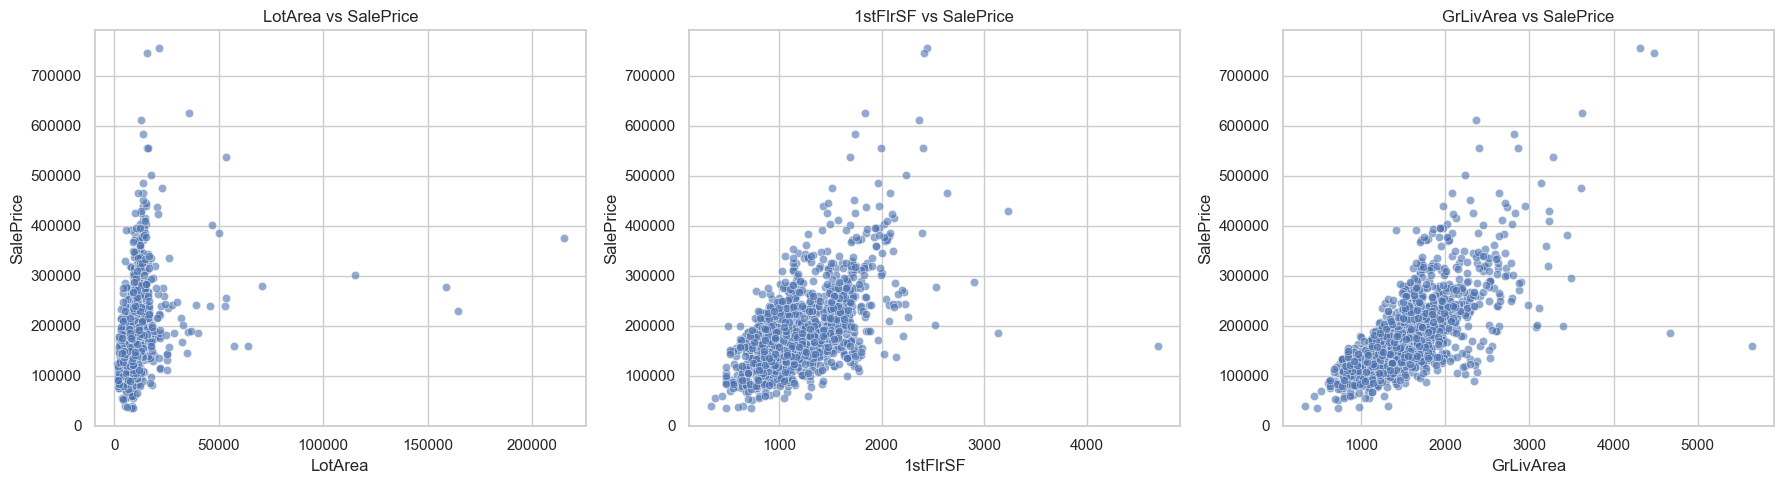

In [33]:
# Your code here - import relevant library, create scatter plots
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# Set the plot style
sns.set(style="whitegrid")

# Define features to plot against SalePrice
features = ['LotArea', '1stFlrSF', 'GrLivArea']

# Create subplots
plt.figure(figsize=(18, 5))

for i, feature in enumerate(features):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(data=ames_subset, x=feature, y='SalePrice', alpha=0.6)
    plt.title(f'{feature} vs SalePrice')
    plt.xlabel(feature)
    plt.ylabel('SalePrice')

plt.tight_layout()
plt.show()

In [34]:
# Your written answer here - do these seem like good candidates for linear regression?
""" 
Yes — to varying degrees, these features can be considered good candidates for linear regression, but with some caveats:

Feature	   Linearity	    Outliers	                Recommendation
LotArea 	Weak-Moderate	 Yes	                   Try log scale,consider trimming outliers
1stFlrSF	Moderate	     Few	                   Good candidate
GrLivArea	Strong	         Possibly	               Very good candidate

"""

' \nYes — to varying degrees, these features can be considered good candidates for linear regression, but with some caveats:\n\nFeature\t   Linearity\t    Outliers\t                Recommendation\nLotArea \tWeak-Moderate\t Yes\t                   Try log scale,consider trimming outliers\n1stFlrSF\tModerate\t     Few\t                   Good candidate\nGrLivArea\tStrong\t         Possibly\t               Very good candidate\n\n'

## Step 2: Build a Simple Linear Regression Model

Set the dependent variable (`y`) to be the `SalePrice`, then choose one of the features shown in the subset above to be the baseline independent variable (`X`).

Build a linear regression using StatsModels, describe the overall model performance, and interpret its coefficients.

In [35]:
# Your code here - define y and baseline X
# Step 1: Define the dependent and independent variables
X_baseline = ames_subset['GrLivArea']
y = ames_subset['SalePrice']

In [36]:
# Your code here - import StatsModels, fit baseline model, display results
import statsmodels.api as sm
model = sm.OLS(y, sm.add_constant(X_baseline)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     1471.
Date:                Mon, 14 Apr 2025   Prob (F-statistic):          4.52e-223
Time:                        03:23:04   Log-Likelihood:                -18035.
No. Observations:                1460   AIC:                         3.607e+04
Df Residuals:                    1458   BIC:                         3.608e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.857e+04   4480.755      4.144      0.000    9779.612    2.74e+04
GrLivArea    107.1304      2.794     38.348      0.000     101.650     112.610
==============================================================================
Omnibus:                      261.166   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3432.287
Skew:                           0.410   Prob(JB):                         0.00
Kurtosis:                      10.467   Cond. No.                     4.90e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.9e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Your written answer here - interpret model results

""" 
The model is statistically significant overall with an F-statistic p-value well below 0.05
The model explains about 50% of the variance in SalesPrice
The model coefficients (const and GrLiveArea) are both statistically significant with t-statistic p-values well below 0.05






"""

' \nThe model is statistically significant overall with an F-statistic p-value well below 0.05\nThe model explains about 50% of the variance in SalesPrice\nThe model coefficients (const and GrLiveArea) are both statistically significant witha t-staistic p-values well below 0.05\n\n\n\n\n\n\n'

## Step 3: Build a Multiple Linear Regression Model

For this model, use **all of** the features in `ames_subset`.

In [38]:
# Your code here - define X
# Step 1: Define the independent variables (X) and the dependent variable (y)
X_second = ames_subset[['LotArea', '1stFlrSF', 'GrLivArea']]
y = ames_subset['SalePrice']



In [39]:
# Your code here - fit model and display results
# Step 3: Build and fit the model
mlr_model = sm.OLS(y, sm.add_constant(X_second)).fit()

# Step 4: Print the summary
mlr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.564
Method:                 Least Squares   F-statistic:                     630.3
Date:                Mon, 14 Apr 2025   Prob (F-statistic):          1.57e-262
Time:                        03:23:04   Log-Likelihood:                -17936.
No. Observations:                1460   AIC:                         3.588e+04
Df Residuals:                    1456   BIC:                         3.590e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.431e+04   4776.331     -2.997      0.003   -2.37e+04   -4944.183
LotArea        0.2841      0.145      1.956      0.051      -0.001       0.569
1stFlrSF      60.2866      4.388     13.739      0.000      51.679      68.894
GrLivArea     80.6061      3.193     25.248      0.000      74.344      86.869
==============================================================================
Omnibus:                      399.604   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13445.161
Skew:                          -0.588   Prob(JB):                         0.00
Kurtosis:                      17.820   Cond. No.                     5.07e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.07e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [40]:
# Your written answer here - interpret model results. Does this model seem better than the previous one?
""" 
The model is statistically significant overall with an F-statistic p-value well below 0.05 
The model explains about 57% of the variance in SalesPrice.This is a moderate improvement compared to the simple linear regression
The model coefficients (const,1stFlrSF and GrLivArea are all statistically significant, with t-statistic p-values well below 0.05) while LotArea is not statistically significant with a t-statistic p-value  well above 0.05

LotArea	0.2841 coefficient Marginally significant. Every 1 extra sq ft of lot size adds ~$0.28 to SalePrice, but borderline insignificant.
GrLivArea	80.61 coefficient Still very strong, but coefficient dropped from 107 → 81 due to shared variance with other variables.
1stFlrSF	60.29 coefficient Strongly significant. Each extra sq ft on 1st floor → ~$60 increase in SalePrice.
const	-14,310	0.003	Intercept, not usually interpreted in isolation.
The drop in GrLivArea's coefficient shows shared explanatory power with 1stFlrSF and LotArea. In real-world terms, these variables are likely correlated — e.g., bigger 1st floors often mean more overall living area.

Model 2 fits better and captures more variance — a good improvement!

Coefficients are interpretable and mostly significant.

Model 2 is clearly better fitting — higher R² of about 6%

"""

" \nThe model is statistically significant overall with an F-statistic p-value well below 0.05 \nThe model explains about 57% of the variance in SalesPrice.This is a moderate improvement compared to the simple linear regression\nThe model coefficients (const,1stFlrSF and GrLivArea are all statistically significant, with t-statistic p-values well below 0.05) while LotArea is not statistically significant with a t-statistic p-value  well above 0.05\n\nLotArea\t0.2841 coefficient Marginally significant. Every 1 extra sq ft of lot size adds ~$0.28 to SalePrice, but borderline insignificant.\nGrLivArea\t80.61 coefficient Still very strong, but coefficient dropped from 107 → 81 due to shared variance with other variables.\n1stFlrSF\t60.29 coefficient Strongly significant. Each extra sq ft on 1st floor → ~$60 increase in SalePrice.\nconst\t-14,310\t0.003\tIntercept, not usually interpreted in isolation.\nThe drop in GrLivArea's coefficient shows shared explanatory power with 1stFlrSF and LotA

## Step 4: Create Partial Regression Plots for Features

Using your model from Step 3, visualize each of the features using partial regression plots.

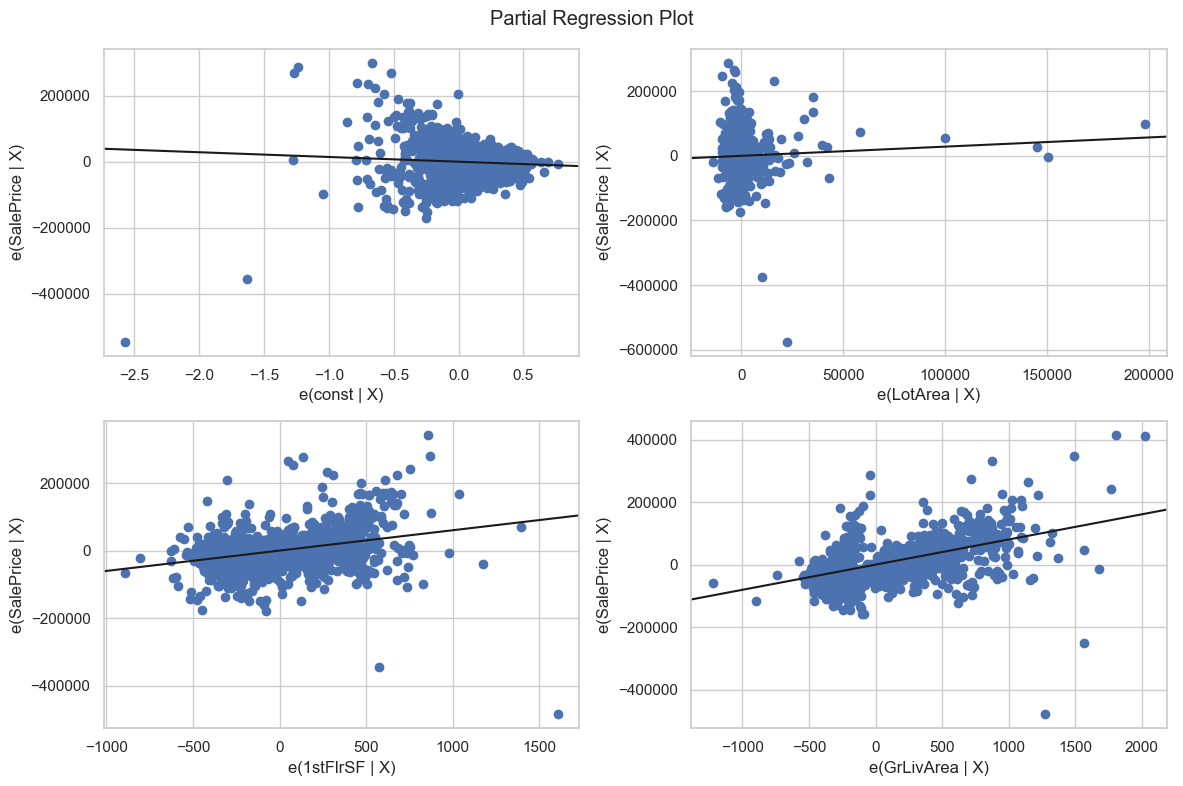

In [41]:
# Your code here - create partial regression plots for each predictor
# Partial regression plots for each predictor
fig = plt.figure(figsize=(12, 8))
sm.graphics.plot_partregress_grid(mlr_model, fig=fig)
plt.tight_layout()
plt.show()

In [42]:
# Your written answer here - explain what you see, and how this relates
# to what you saw in Step 1. What do you notice?

""" 
Feature	        Step 1 (Raw)	                    Step 4 (Partial Regression)	                        Interpretation
LotArea	        Weak positive,outliers	            Weak trend remains, still noisy	                    Not a strong unique predictor
1stFlrSF        Clear positive,moderate spread	    Positive effect remains, some multicollinearity	    Contributes, but overlaps with GrLivArea
GrLivArea	    Strongest positive linear trend	    Strongest adjusted effect as well	                Best independent predictor

"""

' \nFeature\t        Step 1 (Raw)\t                    Step 4 (Partial Regression)\t                        Interpretation\nLotArea\t        Weak positive,outliers\t            Weak trend remains, still noisy\t                    Not a strong unique predictor\n1stFlrSF        Clear positive,moderate spread\t    Positive effect remains, some multicollinearity\t    Contributes, but overlaps with GrLivArea\nGrLivArea\t    Strongest positive linear trend\t    Strongest adjusted effect as well\t                Best independent predictor\n\n'

## Level Up (Optional)

Re-create this model in scikit-learn, and check if you get the same R-Squared and coefficients.

In [43]:
# Your code here - import linear regression from scikit-learn and create and fit model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Define features (X) and target (y)
X = ames_subset[['LotArea', '1stFlrSF', 'GrLivArea']]
y = ames_subset['SalePrice']

# Fit the model
lr = LinearRegression()
lr.fit(X, y)

# Predict and evaluate
y_pred = lr.predict(X)
r2 = r2_score(y, y_pred)

In [44]:
# Your code here - compare R-Squared
# Compare R-squared
r2 = r2_score(y, y_pred)
print(" R-squared (scikit-learn):", round(r2, 3))

 R-squared (scikit-learn): 0.565


In [45]:
# Your code here - compare intercept and coefficients
# Coefficients
print("\n Intercept:", round(lr.intercept_, 2))
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})
print("\n Coefficients:")
print(coef_df)


 Intercept: -14313.41

 Coefficients:
     Feature  Coefficient
0    LotArea     0.284134
1   1stFlrSF    60.286646
2  GrLivArea    80.606058


## Summary
Congratulations! You fitted your first multiple linear regression model on the Ames Housing data using StatsModels.